In [1]:
from pathlib import Path

import colorcet as cc
import equinox as eqx
import grain
import h5py
import jax
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from context_flux_no.data.sources import ZarrWellDatasetSource
from context_flux_no.plotting.lineplots import plot_mean_and_std
from context_flux_no.training.io import load_model
from einops import rearrange
from tqdm import tqdm


plt.style.use("context_flux_no.plotting.styles.dash_gridded")

COLOR_DICT = {
    "DPOT": cc.cm.glasbey_bw(85),
    "ICON": cc.cm.glasbey_bw(1),
    "DISCO": cc.cm.glasbey_bw(68),
    "HyperFluxFNOLocal": cc.cm.glasbey_bw(41),
    "HyperFluxFNOLocal2D": cc.cm.glasbey_bw(41),
}

LABEL_DICT = {
    "DPOT": "DPOT",
    "ICON": "ICON",
    "DISCO": "DISCO",
    "HyperFluxFNOLocal": "HFluxNO (Ours)",
    "HyperFluxFNOLocal2D": "HFluxNO (Ours)",
}
datadir = Path("../../data")
checkpoint_dir = Path("../../checkpoints")

jax.config.update("jax_default_device", jax.devices("gpu")[0])

In [12]:
with h5py.File(f"../../data/analysis/cubicflux_2d_long_rollout.hdf5", "r") as f:
    f.visititems(
        lambda name, obj: print(name, type(obj).__name__, getattr(obj, "shape", ""))
    )

DISCO Group 
DISCO/l2 Dataset (3, 10000, 80)
DISCO/l_inf Dataset (3, 10000, 80)
DISCO/mse Dataset (3, 10000, 80)
DPOT Group 
DPOT/l2 Dataset (3, 10000, 80)
DPOT/l_inf Dataset (3, 10000, 80)
DPOT/mse Dataset (3, 10000, 80)
HyperFluxFNOLocal2D Group 
HyperFluxFNOLocal2D/l2 Dataset (3, 10000, 80)
HyperFluxFNOLocal2D/l_inf Dataset (3, 10000, 80)
HyperFluxFNOLocal2D/mse Dataset (3, 10000, 80)
t_future Dataset (80,)


In [13]:
with h5py.File(f"../../data/analysis/cubic_1d_long_rollout.hdf5", "r") as f:
    f.visititems(
        lambda name, obj: print(name, type(obj).__name__, getattr(obj, "shape", ""))
    )

DISCO Group 
DISCO/l2 Dataset (3, 10000, 79)
DISCO/l_inf Dataset (3, 10000, 79)
DPOT Group 
DPOT/l2 Dataset (3, 10000, 79)
DPOT/l_inf Dataset (3, 10000, 79)
HyperFluxFNOLocal Group 
HyperFluxFNOLocal/l2 Dataset (3, 10000, 79)
HyperFluxFNOLocal/l_inf Dataset (3, 10000, 79)


In [ ]:
import matplotlib as mpl
from matplotlib.lines import Line2D


COLORS = {
    "HFluxNO": cc.cm.glasbey_bw(41),
    "DPOT": cc.cm.glasbey_bw(85),
    "DISCO": cc.cm.glasbey_bw(68),
}
MODEL_ORDER = ["HFluxNO", "DPOT", "DISCO"]
# map h5 group names -> paper names
LABEL = {
    "HyperFluxFNOLocal": "HFluxNO",
    "HyperFluxFNOLocal2D": "HFluxNO",
    "DPOT": "DPOT",
    "DISCO": "DISCO",
}
# family keys -> Table 2 names, in Table 2 order
FAMILY = {
    "cubic_1d": "1D cubic",
    "shallow_water_1d": "1D shallow water",
    "burgers_1d": "1D viscous Burgers",
    "cubicflux_2d": "2D cubic",
    "euler_2d": "2D Euler",
}
RC = {
    "font.family": "serif",
    "font.size": 7,
    "axes.titlesize": 7.5,
    "axes.labelsize": 7.5,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
}


def summarize(l2: np.ndarray, stat: str = "median"):
    """l2: (S, B, T) or (B, T) -> (center, lo, hi), each (T,)."""
    x = l2.reshape(-1, l2.shape[-1])  # pool seeds x ICs
    x = np.where(np.isfinite(x), x, np.nan)  # diverged trajectories -> nan
    if stat == "median":
        c = np.nanmedian(x, axis=0)
        lo, hi = np.nanpercentile(x, [25, 75], axis=0)
    elif stat == "geo":
        lx = np.log(np.clip(x, 1e-12, None))
        m, s = np.nanmean(lx, axis=0), np.nanstd(lx, axis=0)
        c, lo, hi = np.exp(m), np.exp(m - s), np.exp(m + s)
    else:
        raise ValueError(stat)
    return c, lo, hi


def fig_rollout_curves(
    data: dict,
    dt: float,
    k: int = 20,
    stat: str = "median",
    ylim=(1e-3, 1e1),
    out: str | None = None,
):
    """data[family_key][h5_group_name] = l2 array (S, B, T) or (B, T)."""
    fams = [f for f in FAMILY if f in data]
    with mpl.rc_context(RC):
        fig, axes = plt.subplots(
            1,
            len(fams),
            figsize=(5.5, 1.55),
            sharex=True,
            sharey=True,
            gridspec_kw={"wspace": 0.08},
        )
        for ax, fam in zip(axes, fams):
            for name in MODEL_ORDER:
                key = next((g for g, n in LABEL.items() if n == name), None)
                if key not in data[fam]:
                    continue
                c, lo, hi = summarize(np.asarray(data[fam][key]), stat)
                t = np.arange(1, len(c) + 1) * dt
                ax.fill_between(t, lo, hi, color=COLORS[name], alpha=0.18, lw=0)
                ax.plot(t, c, color=COLORS[name], lw=1.2)
            ax.axvline(k * dt, color="0.45", lw=0.6, ls=(0, (3, 2)))
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_ylim(*ylim)
            ax.set_title(FAMILY[fam])
            ax.grid(True, which="major", color="0.9", lw=0.5)
            ax.set_axisbelow(True)
            for sp in ("top", "right"):
                ax.spines[sp].set_visible(False)
            ax.tick_params(length=2, width=0.5)
        axes[0].set_ylabel(r"Rel.\ $\ell^2$ error")
        axes[0].text(
            k * dt,
            ylim[1] * 0.55,
            r"$k\,\Delta t$",
            fontsize=6,
            color="0.35",
            ha="right",
            va="top",
            rotation=90,
        )
        fig.supxlabel(r"$t$", fontsize=7.5, y=-0.04)
        handles = [
            Line2D([], [], color=COLORS[m], lw=1.5, label=m) for m in MODEL_ORDER
        ]
        fig.legend(
            handles=handles,
            ncol=3,
            loc="lower center",
            bbox_to_anchor=(0.5, 1.0),
            frameon=False,
            columnspacing=1.5,
            handlelength=1.6,
        )
        if out:
            fig.savefig(out, bbox_inches="tight", pad_inches=0.02, dpi=600)
        return fig

In [ ]:
data = {}
for fam in FAMILY:
    with h5py.File(f"../../data/analysis/{fam}_long_rollout.hdf5", "r") as f:
        data[fam] = {g: f[g]["l2"][()] for g in f if isinstance(f[g], h5py.Group)}
data["cubicflux_2d"]["HyperFluxFNOLocal"] = data["cubicflux_2d"]["HyperFluxFNOLocal2D"]

In [38]:
data["cubicflux_2d"]

{'DISCO': array([[[8.31431709e-03, 1.46774286e-02, 2.06679124e-02, ...,
          4.32850838e+00, 4.56234360e+00, 4.80834246e+00],
         [6.26475038e-03, 9.71101224e-03, 1.31117990e-02, ...,
          2.35603189e+00, 2.47520900e+00, 2.59928226e+00],
         [6.54105470e-03, 1.01541458e-02, 1.35311345e-02, ...,
          4.31276274e+00, 4.52091932e+00, 4.74556398e+00],
         ...,
         [3.75732640e-03, 7.07093300e-03, 1.00953868e-02, ...,
          2.41805211e-01, 2.61540651e-01, 2.84458727e-01],
         [3.85538791e-03, 7.07521662e-03, 9.69236344e-03, ...,
          3.30897242e-01, 3.65952700e-01, 4.05902088e-01],
         [3.49632534e-03, 5.94616076e-03, 7.82070402e-03, ...,
          1.60891795e+00, 1.75717807e+00, 1.91710842e+00]],
 
        [[9.67001449e-03, 1.68976858e-02, 2.32290551e-02, ...,
          8.99707377e-01, 9.24974382e-01, 9.49881852e-01],
         [6.29219366e-03, 1.08782304e-02, 1.48869222e-02, ...,
          8.76744568e-01, 8.99036229e-01, 9.21257734e-01]

/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


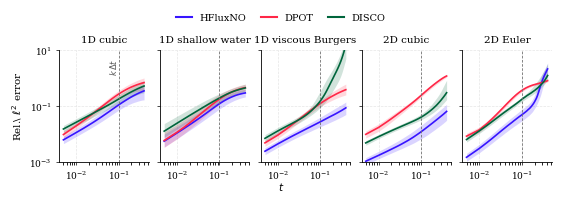

In [44]:
fig = fig_rollout_curves(data, dt=0.005, k=20, out="../../figures/rollout_l2.pdf")

(3, 10000, 79)
(3, 10000, 79)
(3, 10000, 79)
(3, 8952, 81)
(3, 8952, 81)
(3, 8952, 81)
(3, 10000, 81)
(3, 10000, 81)
(3, 10000, 81)
(3, 10000, 80)
(3, 10000, 80)
(3, 10000, 80)
(3, 1000, 81)
(3, 1000, 81)
(3, 1000, 81)


/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:188: RuntimeWarning: invalid value encountered in subtract
  x = um.subtract(arr, arrmean, out=...)


(0.005, 1)

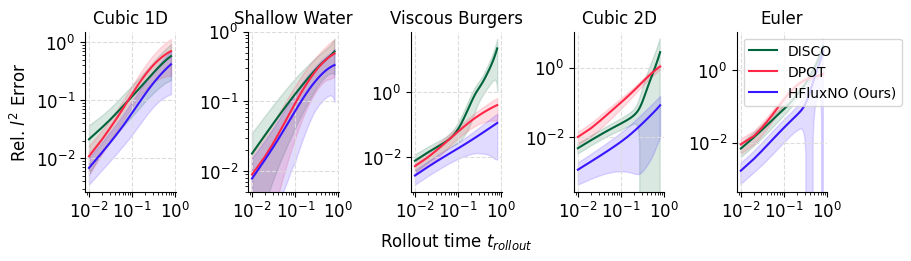

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(9, 2.5), constrained_layout=True, sharex=True)

DATASET_NAME_DICT = {
    "cubic_1d": "Cubic 1D",
    "shallow_water_1d": "Shallow Water",
    "burgers_1d": "Viscous Burgers",
    "cubicflux_2d": "Cubic 2D",
    "euler_2d": "Euler",
}
dt = 0.01
for ax, dataset_name in zip(axes, DATASET_NAME_DICT.keys()):
    with h5py.File(f"../../data/analysis/{dataset_name}_long_rollout.hdf5", "r") as f:
        for model_type, res in f.items():
            if not isinstance(res, h5py.Group):
                continue

            # for i in range(4):
            #     ax.axvline(x=(5 * 2**i - 1) * dt, ls="--", color="gray", alpha=0.7)
            l2 = res["l2"][0]
            ax = plot_mean_and_std(
                ax,
                np.arange(1, l2.shape[1] + 1) * dt,
                l2,
                color=COLOR_DICT[model_type],
                label=LABEL_DICT[model_type],
                alpha_band=0.15,
            )

        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.set_title(DATASET_NAME_DICT[dataset_name], fontsize="medium")
fig.supxlabel("Rollout time $t_{rollout}$", fontsize="medium")
axes[0].set_ylabel("Rel. $l^2$ Error")
axes[-1].legend(fontsize="small", loc="upper left")
axes[1].set_ylim((5e-3, 1))
# fig.savefig("../../figures/fig2/rollout_l2.pdf", dpi=500)

## Make Figure 3

In [31]:
"""Fig. 3, single file: rollout error curves (top) + Euler schlieren (bottom).
 
Both rows are drawn in ONE figure at the final page width (5.5 in) with one
rc (7 pt serif), so the fonts of the two halves match by construction and
nothing is rescaled by \\includegraphics.
 
Bottom layout
    "1x8" : one row, [reference, HFluxNO, DPOT, DISCO] x two times, the two
            time groups separated by a small gap and labelled above.  Tiles
            are ~0.6 in; total figure height ~2.3 in.   (recommended)
    "2x4" : rows = times, cols = reference + models (the earlier fig_main
            block).  Tiles ~1.1 in; total figure height ~3.9 in.
 
Inputs
    data[family_key][h5_group] : l2 array (S, B, T) or (B, T)   (as fig_rollout_curves)
    u_data, u_pred_dict, i, t_idxs, dx : as fig_euler_rollout.fig_main
"""


import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.lines import Line2D


COLORS = {
    "HFluxNO": cc.cm.glasbey_bw(41),
    "DPOT": cc.cm.glasbey_bw(85),
    "DISCO": cc.cm.glasbey_bw(68),
}
CURVE_ORDER = ["HFluxNO", "DPOT", "DISCO"]
# map h5 group names -> paper names
LABEL = {
    "HyperFluxFNOLocal": "HFluxNO",
    "HyperFluxFNOLocal2D": "HFluxNO",
    "DPOT": "DPOT",
    "DISCO": "DISCO",
}
# family keys -> Table 2 names, in Table 2 order
FAMILY = {
    "cubic_1d": "1D cubic",
    "shallow_water_1d": "1D shallow water",
    "burgers_1d": "1D viscous Burgers",
    "cubicflux_2d": "2D cubic",
    "euler_2d": "2D Euler",
}
RC = {
    "font.family": "serif",
    "font.size": 7,
    "axes.titlesize": 7.5,
    "axes.labelsize": 7.5,
    "xtick.labelsize": 6.5,
    "ytick.labelsize": 6.5,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
}


def summarize(l2: np.ndarray, stat: str = "median"):
    """l2: (S, B, T) or (B, T) -> (center, lo, hi), each (T,)."""
    x = l2.reshape(-1, l2.shape[-1])  # pool seeds x ICs
    x = np.where(np.isfinite(x), x, np.nan)  # diverged trajectories -> nan
    if stat == "median":
        c = np.nanmedian(x, axis=0)
        lo, hi = np.nanpercentile(x, [25, 75], axis=0)
    elif stat == "geo":
        lx = np.log(np.clip(x, 1e-12, None))
        m, s = np.nanmean(lx, axis=0), np.nanstd(lx, axis=0)
        c, lo, hi = np.exp(m), np.exp(m - s), np.exp(m + s)
    else:
        raise ValueError(stat)
    return c, lo, hi


RC = {
    "font.family": "serif",
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    # the layout below is placed by hand in inches; any automatic layout
    # engine inherited from the notebook (tight_layout on draw, constrained
    # layout) would stretch the gridspec axes over the tiles
    "figure.autolayout": False,
    "figure.constrained_layout.use": False,
}

CB_LABEL = r"$\log_{10}|\nabla\rho|/G_{\mathrm{ref}}$"

import colorcet as cc


DISPLAY_NAME = {"HyperNeuralOperator": "HFluxNO", "DPOT": "DPOT", "DISCO": "DISCO"}
PRED_ORDER = ["HyperNeuralOperator", "DPOT", "DISCO"]  # keys of u_pred_dict
FIELD_CMAP = {"rho": cc.cm.fire, "rho_e": cc.cm.bmy, "p": "cividis", "speed": cc.cm.kbc}


def grad_mag_periodic(f: np.ndarray, dx: float) -> np.ndarray:
    """|grad f| by 2nd-order central differences with periodic wrap; f: (..., Nx, Ny)."""
    gx = (np.roll(f, -1, axis=-2) - np.roll(f, 1, axis=-2)) / (2 * dx)
    gy = (np.roll(f, -1, axis=-1) - np.roll(f, 1, axis=-1)) / (2 * dx)
    return np.sqrt(gx**2 + gy**2)


def _tile(ax, img, **kw):
    im = ax.imshow(img, interpolation="nearest", **kw)
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linewidth(0.4)
    return im


# ------------------------------------------------------------------ top row
def _draw_curves(fig, sub, data, dt, k, stat, ylim):
    fams = [f for f in FAMILY if f in data]
    gs = GridSpecFromSubplotSpec(1, len(fams), subplot_spec=sub, wspace=0.08)
    axes = []
    for j, fam in enumerate(fams):
        ax = fig.add_subplot(
            gs[0, j], sharex=axes[0] if axes else None, sharey=axes[0] if axes else None
        )
        axes.append(ax)
        for name in CURVE_ORDER:
            key = next((g for g, n in LABEL.items() if n == name), None)
            if key not in data[fam]:
                continue
            c, lo, hi = summarize(np.asarray(data[fam][key]), stat)
            t = np.arange(1, len(c) + 1) * dt
            ax.fill_between(t, lo, hi, color=COLORS[name], alpha=0.18, lw=0)
            ax.plot(t, c, color=COLORS[name], lw=1.1)
        ax.axvline(k * dt, color="0.45", lw=0.6, ls=(0, (3, 2)))
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylim(*ylim)
        ax.set_title(FAMILY[fam], pad=2)
        ax.grid(True, which="major", color="0.9", lw=0.5)
        ax.set_axisbelow(True)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
        ax.tick_params(length=2, width=0.5, pad=1.5)
        ax.set_xlabel(r"$t$", labelpad=0.5)
        if j > 0:
            ax.tick_params(labelleft=False)
    axes[0].set_ylabel(r"Rel. $\ell^2$ error", labelpad=1)
    axes[0].text(
        k * dt,
        ylim[1] * 0.6,
        r"$k\Delta t$",
        fontsize=6,
        color="0.35",
        ha="right",
        va="top",
        rotation=90,
    )
    handles = [Line2D([], [], color=COLORS[m], lw=1.5, label=m) for m in CURVE_ORDER]
    return axes, handles


# --------------------------------------------------------------- bottom row
def _schlieren_panels(u_data, u_pred_dict, i, t_idxs, dx, vq=(50, 99.5)):
    """Returns dict[(t, col_name)] = log10(|grad rho|/G_ref), plus (vmin, vmax)
    set from the reference: vmin = median, vmax = 99.5th percentile, as in the
    notebook version of fig_main."""
    cols = ["reference"] + PRED_ORDER
    g_ref = max(grad_mag_periodic(u_data[i, t, 0], dx).max() for t in t_idxs)
    panels, ref_vals = {}, []
    for t in t_idxs:
        for name in cols:
            rho = u_data[i, t, 0] if name == "reference" else u_pred_dict[name][i, t, 0]
            g = np.log10(np.maximum(grad_mag_periodic(rho, dx) / g_ref, 1e-6))
            panels[(t, name)] = g
            if name == "reference":
                ref_vals.append(g.ravel())
    vmin, vmax = np.percentile(np.concatenate(ref_vals), vq)
    return cols, panels, float(vmin), float(vmax)


def _tlabel(t, dt):
    return rf"$t = {(t + 1) * dt:.3g}$ ({t + 1} steps)"


# ------------------------------------------------------------------- driver
def fig3_combined(
    data,
    u_data,
    u_pred_dict,
    i,
    t_idxs,
    dt=0.005,
    dx=1 / 128,
    k=20,
    layout="1x8",
    stat="median",
    ylim=(1e-3, 1e1),
    cmap=None,
    cbar="none",
    out=None,
    width=5.5,
):
    """Absolute layout in inches: [legend][curves][gap][time labels][tiles]."""
    cmap = cmap or FIELD_CMAP["rho_e"]
    left = 0.46 if cbar == "left" else 0.42  # margin (in): y-label (and left colourbar)
    right = 0.40 if cbar == "right" else 0.08  # colourbar only if on the right
    h_cbar = 0.24 if cbar == "bottom" else 0.0  # horizontal bar + its label
    top_pad, h_leg = 0.02, 0.14  # legend strip above the curves
    h_title = 0.12  # curve-panel titles
    h_curves = 1.05  # curve axes proper
    h_xlab = 0.22  # x tick labels + "t"
    gap = 0.10
    h_grp = 0.14 if layout == "1x8" else 0.0  # time-group labels
    h_coltitle = 0.11  # reference/HFluxNO/... titles
    w_tiles = width - left - right
    if layout == "1x8":
        tile = (w_tiles - 0.18 - 6 * 0.03) / 8  # 8 tiles, 0.18 in between groups
        h_tiles = tile
    else:
        tile = (w_tiles - 3 * 0.04) / 4
        h_tiles = 2 * tile + 0.04
    height = (
        top_pad
        + h_leg
        + h_title
        + h_curves
        + h_xlab
        + gap
        + h_grp
        + h_coltitle
        + h_tiles
        + 0.03
        + h_cbar
    )
    with mpl.rc_context(RC):
        fig = plt.figure(figsize=(width, height), layout="none")
        H = height
        # --- top row via a gridspec confined to its inch band
        y_t0 = (0.03 + h_cbar) / H  # bottom of the tiles
        y_c0 = (0.03 + h_cbar + h_tiles + h_coltitle + h_grp + gap + h_xlab) / H
        y_c1 = y_c0 + h_curves / H
        gs_top = GridSpec(
            1,
            1,
            figure=fig,
            left=left / width,
            right=1 - right / width,
            bottom=y_c0,
            top=y_c1,
        )
        axes_c, handles = _draw_curves(fig, gs_top[0], data, dt, k, stat, ylim)
        fig.legend(
            handles=handles,
            ncol=3,
            loc="lower center",
            bbox_to_anchor=(0.5, y_c1 + h_title / H),
            frameon=False,
            columnspacing=1.5,
            handlelength=1.6,
            borderaxespad=0.0,
        )
        # --- bottom row, tiles placed by hand
        cols = ["reference"] + PRED_ORDER
        _, panels, vmin, vmax = _schlieren_panels(u_data, u_pred_dict, i, t_idxs, dx)
        axes_s = []
        if layout == "1x8":
            x = left
            for gi, t in enumerate(t_idxs):
                gx0 = x
                for c, name in enumerate(cols):
                    ax = fig.add_axes([x / width, y_t0, tile / width, tile / H])
                    im = _tile(ax, panels[(t, name)], cmap=cmap, vmin=vmin, vmax=vmax)
                    ax.set_title("reference" if c == 0 else DISPLAY_NAME[name], pad=1.5)
                    axes_s.append(ax)
                    x += tile + 0.03
                gx1 = x - 0.03
                fig.text(
                    0.5 * (gx0 + gx1) / width,
                    y_t0 + (tile + h_coltitle) / H,
                    _tlabel(t, dt),
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )
                x += 0.18 - 0.03
        else:
            for r, t in enumerate(t_idxs):
                y = y_t0 + (len(t_idxs) - 1 - r) * (tile + 0.04) / H
                for c, name in enumerate(cols):
                    ax = fig.add_axes(
                        [(left + c * (tile + 0.04)) / width, y, tile / width, tile / H]
                    )
                    im = _tile(ax, panels[(t, name)], cmap=cmap, vmin=vmin, vmax=vmax)
                    if r == 0:
                        ax.set_title(
                            "reference" if c == 0 else DISPLAY_NAME[name], pad=1.5
                        )
                    if c == 0:
                        ax.set_ylabel(
                            rf"$t = {(t + 1) * dt:.3g}$" + f"\n({t + 1} steps)",
                            rotation=0,
                            ha="right",
                            va="center",
                            labelpad=4,
                        )
                    axes_s.append(ax)
        # colourbar
        if cbar == "right":
            cax = fig.add_axes(
                [(width - right + 0.05) / width, y_t0, 0.06 / width, h_tiles / H]
            )
            cb = fig.colorbar(im, cax=cax)
            cb.ax.tick_params(length=2, width=0.4, labelsize=6, pad=1)
            cb.set_label(CB_LABEL, fontsize=6.5, labelpad=2)
        elif cbar == "left":
            # bar in the y-label column, ticks/label on its outer side so the
            # tiles keep the same left edge as the curve axes
            cax = fig.add_axes([(left - 0.11) / width, y_t0, 0.05 / width, h_tiles / H])
            cb = fig.colorbar(im, cax=cax)
            cb.ax.yaxis.set_ticks_position("left")
            cb.ax.yaxis.set_label_position("left")
            cb.ax.tick_params(length=2, width=0.4, labelsize=6, pad=1)
            cb.set_label(CB_LABEL, fontsize=6.5, labelpad=2)
        elif cbar == "bottom":
            w_cb = 1.6
            cax = fig.add_axes(
                [
                    (left + 0.5 * (w_tiles - w_cb)) / width,
                    0.16 / H,
                    w_cb / width,
                    0.05 / H,
                ]
            )
            cb = fig.colorbar(im, cax=cax, orientation="horizontal")
            cb.ax.tick_params(length=2, width=0.4, labelsize=6, pad=1)
            cb.set_label(CB_LABEL, fontsize=6.5, labelpad=1)
        # panel letters
        fig.text(
            0.0,
            y_c1 + 0.05,
            "(a)",
            fontsize=7,
            fontweight="bold",
            ha="left",
            va="bottom",
        )
        fig.text(
            0.0,
            y_t0 + h_tiles / H + 0.08,
            "(b)",
            fontsize=7,
            fontweight="bold",
            ha="left",
            va="bottom",
        )
        if out:
            fig.savefig(out, bbox_inches="tight", pad_inches=0.02, dpi=600)
        return fig

In [3]:
data = {}
for fam in FAMILY:
    with h5py.File(f"../../data/analysis/{fam}_long_rollout.hdf5", "r") as f:
        data[fam] = {g: f[g]["l2"][()] for g in f if isinstance(f[g], h5py.Group)}
data["cubicflux_2d"]["HyperFluxFNOLocal"] = data["cubicflux_2d"]["HyperFluxFNOLocal2D"]

In [4]:
checkpoint_dir = Path("../../checkpoints/euler_2d/")

model_paths = {
    "DPOT": "seed=0/26-09-22-02_45_52",
    # "HyperFluxFNOLocal": "seed=10/26-04-30-01:34:48",
    # "DISCO": "seed=0/26-07-18-20:51:57",
    "HyperNeuralOperator": "seed=0/26-09-22-13_04_48",
    "DISCO": "seed=0/26-09-22-02_32_26",
}

source = ZarrWellDatasetSource(
    "../../data/datasets",
    "euler_2d",
    "test",
    exclude_filters=[
        "step",
    ],
    window_size=100,
    # preload_into_ram=True,
)

dataloader = grain.DataLoader(
    data_source=source,
    sampler=grain.samplers.IndexSampler(len(source), shuffle=False, seed=0),
    operations=[grain.transforms.Batch(batch_size=64)],
    worker_count=0,
    # read_options=grain.ReadOptions(num_threads=32, prefetch_buffer_size=1000),
)

dataiter = iter(dataloader)
batch = next(dataiter)


def get_loss_args(source):
    dt = source.metadata_common["temporal_resolution"]
    dxs = source.metadata_common["spatial_resolution"]
    return (dt, *dxs)

dataset_name {'euler_2d'} 1
n_spatial_dims {2} 1
spatial_dims_shape {(128, 128)} 1
field_names {(('rho', 'E'), ('m',), ())} 1
temporal_resolution {np.float32(0.005)} 1
spatial_resolution {(np.float32(0.0078125), np.float32(0.0078125))} 1


In [5]:
u_pred_dict = {}

for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / "OneStepLoss" / path)
    model = eqx.nn.inference_mode(model, True)

    context, u_data = batch[:, :20], batch[:, 20:]
    u_pred = eqx.filter_vmap(
        lambda x, y: model.rollout(x, get_loss_args(source), num_steps=len(y))[0]
    )(context, u_data)

    u_pred_dict[model_type] = u_pred

 33%|███▎      | 1/3 [00:23<00:46, 23.37s/it]/home/jhko725/projects/CONTEXT_FLUX_NO/src/context_flux_no/models/multiphysics/hyperfluxfno/utils.py:73: UserWarning: TRecViTEncoder supports variable in_timesteps. The given 
                    in_timesteps value will be ignored.
  warnings.warn(
ERROR:asyncio:Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jhko725/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x14997f8a2180> is already entered
ERROR:asyncio:Task was destroyed but it is pending!
task: <Task pending name='Task-4121' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-4122' coro=<Kernel.

/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/home/jhko725/projects/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


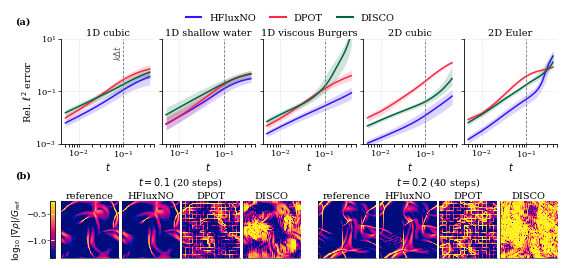

In [32]:
fig = fig3_combined(
    data,
    u_data,
    u_pred_dict,
    i=27,
    t_idxs=[19, 39],
    layout="1x8",
    cbar="left",
    out="../../figures/fig3.pdf",
)
fig

## Compute rolled out trajectories for seed=0, and for a fixed trajectory

In [ ]:
dataset_test = (
    xr.open_dataset(
        datadir
        / "datasets/cubic_no_source/data/test/cubic_no_source_large_test_seed=10.hdf5",
        engine="h5netcdf",
        chunks={},
    )
    .isel(t=slice(None, None, 10))
    .isel({"t": slice(0, 99)})
)
dt = float(dataset_test["t"][1] - dataset_test["t"][0])
dx = float(dataset_test["x"][1] - dataset_test["x"][0])

values = rearrange(dataset_test["values"].values, "pde ic ... -> (pde ic) ...")